<a href="https://colab.research.google.com/github/Meriem-BERRAHOU/Machine-learning-Projects/blob/simple-projects/Mall_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [3]:
mall_customer_data = pd.read_csv('/content/Mall_Customers.csv')
mall_customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
mall_customer_data.shape

(200, 5)

In [5]:
mall_customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
mall_customer_data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
mall_customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
mall_customer_data['Gender'].describe()

,Gender
count,200
unique,2
top,Female
freq,112


In [9]:
#encoding the gender column
encoder = {'Female':0,'Male':1}
mall_customer_data['Gender'] = mall_customer_data['Gender'].map(encoder)
mall_customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
mall_customer_data.drop(['CustomerID'],axis=1,inplace=True)
mall_customer_data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Preprocessing the data

In [18]:
Z = mall_customer_data.iloc[:,[2,3]].values
print(Z)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [24]:
sns.set()

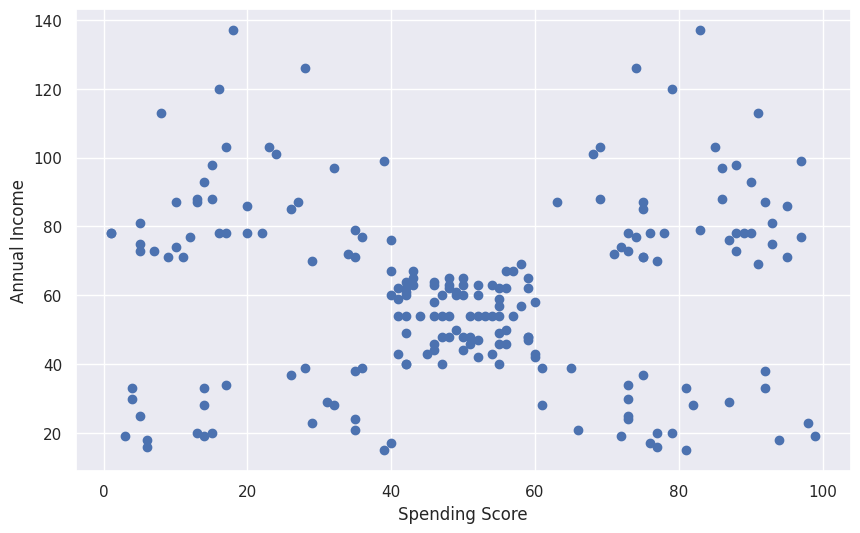

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(mall_customer_data['Spending Score (1-100)'],mall_customer_data['Annual Income (k$)'])
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.show()

Choosing the number of clusters

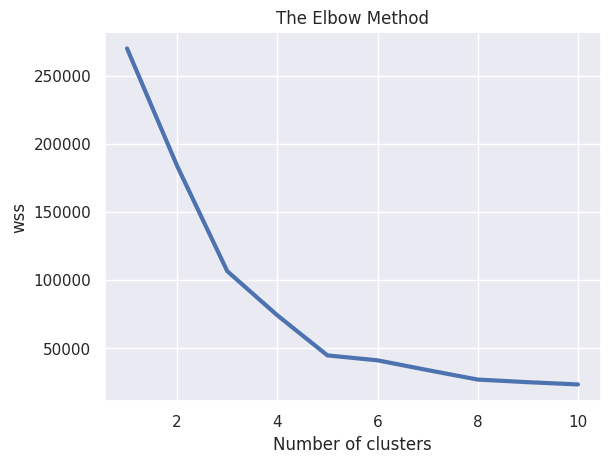

In [33]:
wss=[]

#lopping the k range
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42)
  kmeans.fit(Z)
  wss.append(kmeans.inertia_)

#visualising the elbow method
plt.plot(range(1,11),wss,lw=3)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wss')
plt.show()

Training the data

In [36]:
#training the data with k-means and n_clusters=5
model = KMeans(n_clusters=5,init='k-means++',random_state=42)
#return a label for each data point based on the clustering fro 0 to 4
y_means = model.fit_predict(Z)
print(y_means)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


Visualizing the clusters

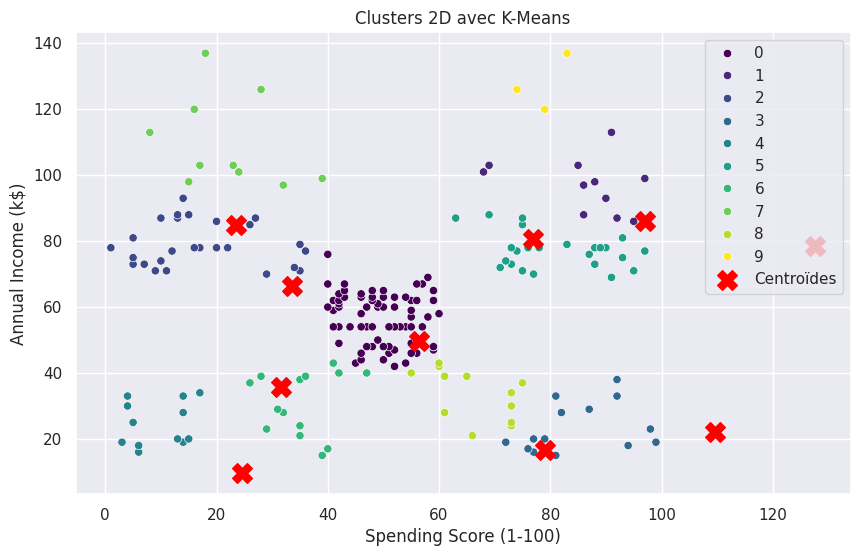

In [40]:
#visualizing data with max clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=mall_customer_data, x='Spending Score (1-100)', y='Annual Income (k$)',
                hue=kmeans.labels_, palette='viridis',
                legend='full')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker='X', s=200, c='red', label='Centroïdes')
plt.title('Clusters 2D avec K-Means')
plt.legend()
plt.show()

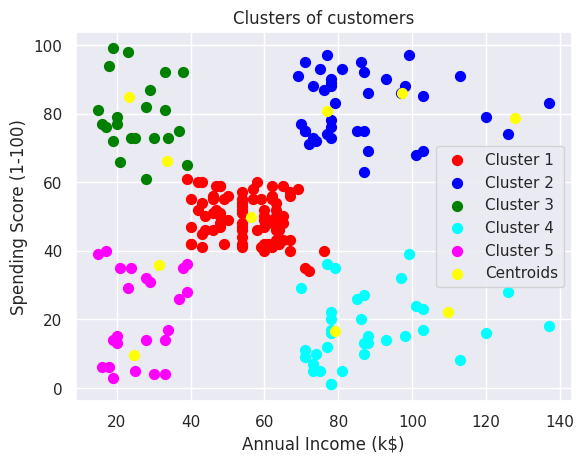

In [45]:
#visualizing data with exact 5 clusters
#plotting the clusters
plt.scatter(Z[y_means == 0, 0], Z[y_means == 0, 1], s = 50, c = 'red', label = 'Cluster 1')
plt.scatter(Z[y_means == 1, 0], Z[y_means == 1, 1], s = 50, c = 'blue', label = 'Cluster 2')
plt.scatter(Z[y_means == 2, 0], Z[y_means == 2, 1], s = 50, c = 'green', label = 'Cluster 3')
plt.scatter(Z[y_means == 3, 0], Z[y_means == 3, 1], s = 50, c = 'cyan', label = 'Cluster 4')
plt.scatter(Z[y_means == 4, 0], Z[y_means == 4, 1], s = 50, c = 'magenta', label = 'Cluster 5')

#plot the centroides
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=50, c='yellow', label='Centroids')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()